In the name of God

# Q1: Analysis of Neural Network Performance Under Adversarial Attacks

In this notebook we will be training a few CNN and ViT networks and test their performance on noisy data and under adversarial attacks, defend against such attacks by using adversarial training and answer a few questions.

## 1-1. Training ResNet on noisy images

In this section we will be using a ResNet model (ResNet34) and train it on the CIFAR-100 dataset with and without noise to investigate the effects of noise on model performance.

### 1-1-1. Loading the dataset

As the first step we will use pytorch to load the dataset, normalise it (for the use in the network) and define the appropriate data loaders

In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import torch
import torchvision
import torchvision.transforms as transforms

transform_clean = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

batch_size = 128

train_set_clean = torchvision.datasets.CIFAR100(
    root='./data', 
    train=True,
    download=True, 
    transform=transform_clean
)
train_loader_clean = torch.utils.data.DataLoader(
    train_set_clean, 
    batch_size=batch_size,
    shuffle=True, 
    num_workers=2
)

test_set = torchvision.datasets.CIFAR100(
    root='./data', 
    train=False,
    download=True, 
    transform=transform_clean
)

test_loader = torch.utils.data.DataLoader(
    test_set, 
    batch_size=batch_size,
    shuffle=False, 
    num_workers=2
)

print(len(train_set_clean))
print(len(test_set))

50000
10000


### 1-1-2. Adding noise

In order to add the noise, we will define a class called AddGaussianNoise that can be used in the transformation part (when we are loading the data) and add the noise to the data (before we normalise it)

In order to verify the process we will visualise a random image and its noisy counterpart.

In [2]:
import numpy as np

class AddGaussianNoise(object):
    def __init__(self, mean=0., std=1.):
        self.std = std
        self.mean = mean

    def __call__(self, tensor):
        noisy_tensor = tensor + torch.randn(tensor.size()) * self.std + self.mean
        return torch.clamp(noisy_tensor, 0., 1.)

    def __repr__(self):
        return self.__class__.__name__ + f'(mean={self.mean}, std={self.std})'

noise_mean = 0
noise_variance = 0.005
noise_std_dev = np.sqrt(noise_variance)

transform_noisy = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(mean=noise_mean, std=noise_std_dev),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

train_set_noisy = torchvision.datasets.CIFAR100(
    root='./data', 
    train=True,
    download=True, 
    transform=transform_noisy
)

train_loader_noisy = torch.utils.data.DataLoader(
    train_set_noisy, 
    batch_size=batch_size,
    shuffle=True, 
    num_workers=2
)

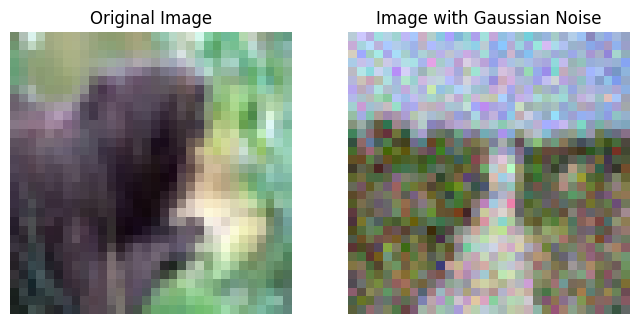

In [3]:
import matplotlib.pyplot as plt

def display_image(image, axes):
    mean = np.array([0.5071, 0.4867, 0.4408])
    std = np.array([0.2675, 0.2565, 0.2761])
    image = image.numpy().transpose((1, 2, 0)) 
    image = std * image + mean
    image = np.clip(image, 0, 1)
    
    axes.imshow(image)
    axes.axis('off')

clean_images, _ = next(iter(train_loader_clean))
noisy_images, _ = next(iter(train_loader_noisy))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].set_title('Original Image')
display_image(clean_images[0], axes=axes[0])

axes[1].set_title('Image with Gaussian Noise')
display_image(noisy_images[0], axes=axes[1])

plt.show()

### 1-1-3. Training the ResNet model

In this section we will use the ResNet34 in the pytorch library (from torchvision.models), define a function to loop and train the model for 20 epochs and save the results to be plotted in the next section. We will do this process once with the normal data and once with the noisy data and compare the results.

We will also try different hyper parameter tuning methods, such as L2 regularization, adding a dropout layer, learning rate scheduler and data augmentation

In [4]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from time import time
import copy

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
def train_and_validate(
        model, 
        train_loader, 
        test_loader, 
        optimizer, 
        criterion, 
        epochs,
        scheduler=None,
        keep_best=False
    ):
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    best_val_acc = 0.0
    best_model_state = None

    start_time = time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0 
        total_train = 0 

        for i, data in enumerate(train_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100 * correct_train / total_train
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0
        with torch.no_grad():
            for data in test_loader:
                images, labels = data[0].to(device), data[1].to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_acc = 100 * correct_val / total_val
        epoch_val_loss = val_loss / len(test_loader)
        history['val_acc'].append(epoch_val_acc)
        history['val_loss'].append(epoch_val_loss)

        if keep_best and epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            print(f"Epoch {epoch + 1}: New best model saved with Val Acc: {best_val_acc:.2f}%")
            
        if scheduler:
            scheduler.step()

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'Train Loss: {epoch_train_loss:.4f} | '
              f'Train Acc: {epoch_train_acc:.2f}% | '
              f'Val Loss: {epoch_val_loss:.4f} | '
              f'Val Acc: {epoch_val_acc:.2f}%')

    end_time = time()
    print(f'Finished Training. Total time: {(end_time - start_time)/60:.2f} minutes')
    
    if keep_best:
        return history, best_model_state
    
    return history

In [5]:
epochs = 20
learning_rate = 0.001
num_classes = 100

model_clean_plain = models.resnet34(weights=None)
model_clean_plain.fc = nn.Linear(model_clean_plain.fc.in_features, num_classes)
model_clean_plain.to(device)

model_noisy_plain = models.resnet34(weights=None)
model_noisy_plain.fc = nn.Linear(model_noisy_plain.fc.in_features, num_classes)
model_noisy_plain.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_clean_plain = optim.Adam(model_clean_plain.parameters(), lr=learning_rate)
optimizer_noisy_plain = optim.Adam(model_noisy_plain.parameters(), lr=learning_rate)


print("Training the model on clean data")
history_clean_plain = train_and_validate(
    model_clean_plain, 
    train_loader_clean,
    test_loader,
    optimizer_clean_plain,
    criterion,
    epochs
)

print()
print("Training the model on noisy data")
history_noisy_plain = train_and_validate(
    model_noisy_plain,
    train_loader_noisy,
    test_loader,
    optimizer_noisy_plain,
    criterion,
    epochs
)

Training the model on clean data
Epoch 1/20 | Train Loss: 3.6740 | Train Acc: 13.98% | Val Loss: 3.3210 | Val Acc: 19.74%
Epoch 2/20 | Train Loss: 2.9238 | Train Acc: 27.01% | Val Loss: 2.9253 | Val Acc: 27.71%
Epoch 3/20 | Train Loss: 2.5297 | Train Acc: 34.56% | Val Loss: 2.5766 | Val Acc: 33.49%
Epoch 4/20 | Train Loss: 2.2309 | Train Acc: 40.93% | Val Loss: 2.4415 | Val Acc: 37.40%
Epoch 5/20 | Train Loss: 1.9903 | Train Acc: 46.32% | Val Loss: 2.5463 | Val Acc: 36.59%
Epoch 6/20 | Train Loss: 1.7550 | Train Acc: 51.39% | Val Loss: 2.4416 | Val Acc: 39.73%
Epoch 7/20 | Train Loss: 1.5296 | Train Acc: 56.82% | Val Loss: 2.4304 | Val Acc: 40.37%
Epoch 8/20 | Train Loss: 1.3169 | Train Acc: 61.96% | Val Loss: 2.3560 | Val Acc: 42.73%
Epoch 9/20 | Train Loss: 1.0996 | Train Acc: 67.16% | Val Loss: 2.5687 | Val Acc: 41.54%
Epoch 10/20 | Train Loss: 0.9028 | Train Acc: 72.75% | Val Loss: 2.5753 | Val Acc: 43.02%
Epoch 11/20 | Train Loss: 0.6975 | Train Acc: 78.41% | Val Loss: 2.7642 | Va

As we can see, the models have clearly overfitted.

In order to see if we can improve the models, next we will add L2 regularization to our models.

In [6]:
epochs = 20
learning_rate = 0.001
num_classes = 100

model_clean_l2 = models.resnet34(weights=None)
model_clean_l2.fc = nn.Linear(model_clean_l2.fc.in_features, num_classes)
model_clean_l2.to(device)

model_noisy_l2 = models.resnet34(weights=None)
model_noisy_l2.fc = nn.Linear(model_noisy_l2.fc.in_features, num_classes)
model_noisy_l2.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_clean_l2 = optim.Adam(
    model_clean_l2.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
optimizer_noisy_l2 = optim.Adam(
    model_noisy_l2.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)


print("Training the model on clean data")
history_clean_l2 = train_and_validate(
    model_clean_l2, 
    train_loader_clean,
    test_loader,
    optimizer_clean_l2,
    criterion,
    epochs
)

print()
print("Training the model on noisy data")
history_noisy_l2 = train_and_validate(
    model_noisy_l2,
    train_loader_noisy,
    test_loader,
    optimizer_noisy_l2,
    criterion,
    epochs
)

Training the model on clean data
Epoch 1/20 | Train Loss: 3.6838 | Train Acc: 13.74% | Val Loss: 3.4427 | Val Acc: 17.89%
Epoch 2/20 | Train Loss: 2.9538 | Train Acc: 26.20% | Val Loss: 3.1499 | Val Acc: 26.54%
Epoch 3/20 | Train Loss: 2.5291 | Train Acc: 34.50% | Val Loss: 2.6710 | Val Acc: 32.14%
Epoch 4/20 | Train Loss: 2.2443 | Train Acc: 40.41% | Val Loss: 2.6370 | Val Acc: 34.55%
Epoch 5/20 | Train Loss: 2.0030 | Train Acc: 45.79% | Val Loss: 2.3540 | Val Acc: 39.05%
Epoch 6/20 | Train Loss: 1.7778 | Train Acc: 50.96% | Val Loss: 2.3918 | Val Acc: 39.73%
Epoch 7/20 | Train Loss: 1.5799 | Train Acc: 55.47% | Val Loss: 2.3717 | Val Acc: 40.66%
Epoch 8/20 | Train Loss: 1.3872 | Train Acc: 60.13% | Val Loss: 2.4002 | Val Acc: 41.24%
Epoch 9/20 | Train Loss: 1.1699 | Train Acc: 65.74% | Val Loss: 2.3594 | Val Acc: 42.98%
Epoch 10/20 | Train Loss: 0.9717 | Train Acc: 71.03% | Val Loss: 2.4417 | Val Acc: 43.72%
Epoch 11/20 | Train Loss: 0.7966 | Train Acc: 75.76% | Val Loss: 2.5102 | Va

Even after adding L2 regularization still both of the models overfitted, with the only difference being that their final accuracy on the training data was reduced, next we will try adding a dropout layer before the final classification layer

In [7]:
epochs = 20
learning_rate = 0.001
num_classes = 100
dropout_rate = 0.5

model_clean_l2_dropout = models.resnet34(weights=None)
model_clean_l2_dropout.fc = nn.Sequential(
    nn.Dropout(p=dropout_rate),
    nn.Linear(model_clean_l2_dropout.fc.in_features, 100)
)
model_clean_l2_dropout.to(device)

model_noisy_l2_dropout = models.resnet34(weights=None)
model_noisy_l2_dropout.fc = nn.Sequential(
    nn.Dropout(p=dropout_rate),
    nn.Linear(model_noisy_l2_dropout.fc.in_features, 100)
)
model_noisy_l2_dropout.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_clean_l2_dropout = optim.Adam(
    model_clean_l2_dropout.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
optimizer_noisy_l2_dropout = optim.Adam(
    model_noisy_l2_dropout.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)


print("Training the model on clean data")
history_clean_l2_dropout = train_and_validate(
    model_clean_l2_dropout, 
    train_loader_clean,
    test_loader,
    optimizer_clean_l2_dropout,
    criterion,
    epochs
)

print()
print("Training the model on noisy data")
history_noisy_l2_dropout = train_and_validate(
    model_noisy_l2_dropout,
    train_loader_noisy,
    test_loader,
    optimizer_noisy_l2_dropout,
    criterion,
    epochs
)

Training the model on clean data
Epoch 1/20 | Train Loss: 4.0224 | Train Acc: 9.35% | Val Loss: 3.5784 | Val Acc: 16.85%
Epoch 2/20 | Train Loss: 3.3572 | Train Acc: 18.85% | Val Loss: 3.0917 | Val Acc: 22.67%
Epoch 3/20 | Train Loss: 3.0299 | Train Acc: 24.75% | Val Loss: 9.1118 | Val Acc: 18.63%
Epoch 4/20 | Train Loss: 2.7266 | Train Acc: 30.63% | Val Loss: 14.8690 | Val Acc: 14.61%
Epoch 5/20 | Train Loss: 2.5572 | Train Acc: 34.04% | Val Loss: 2.6109 | Val Acc: 34.04%
Epoch 6/20 | Train Loss: 2.2812 | Train Acc: 39.44% | Val Loss: 2.3689 | Val Acc: 38.40%
Epoch 7/20 | Train Loss: 2.1003 | Train Acc: 43.35% | Val Loss: 2.2629 | Val Acc: 40.35%
Epoch 8/20 | Train Loss: 1.9370 | Train Acc: 47.26% | Val Loss: 2.2571 | Val Acc: 41.18%
Epoch 9/20 | Train Loss: 1.7723 | Train Acc: 50.85% | Val Loss: 2.2303 | Val Acc: 42.95%
Epoch 10/20 | Train Loss: 1.6065 | Train Acc: 54.59% | Val Loss: 2.1903 | Val Acc: 43.49%
Epoch 11/20 | Train Loss: 1.4453 | Train Acc: 58.18% | Val Loss: 2.3710 | Va

Dropout didn't have much of an effect either so next we will try using schedulers

In [ ]:
from torch.optim.lr_scheduler import StepLR

epochs = 20
learning_rate = 0.001
num_classes = 100
dropout_rate = 0.5

model_clean_l2_dropout_scheduler = models.resnet34(weights=None)
model_clean_l2_dropout_scheduler.fc = nn.Sequential(
    nn.Dropout(p=dropout_rate),
    nn.Linear(model_clean_l2_dropout_scheduler.fc.in_features, 100)
)
model_clean_l2_dropout_scheduler.to(device)

model_noisy_l2_dropout_scheduler = models.resnet34(weights=None)
model_noisy_l2_dropout_scheduler.fc = nn.Sequential(
    nn.Dropout(p=dropout_rate),
    nn.Linear(model_noisy_l2_dropout_scheduler.fc.in_features, 100)
)
model_noisy_l2_dropout_scheduler.to(device)

criterion = nn.CrossEntropyLoss()

scheduler_clean = StepLR(optimizer_clean_plain, step_size=7, gamma=0.1)
scheduler_noisy = StepLR(optimizer_noisy_plain, step_size=7, gamma=0.1)

optimizer_clean_l2_dropout_scheduler = optim.Adam(
    model_clean_l2_dropout_scheduler.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
optimizer_noisy_l2_dropout_scheduler = optim.Adam(
    model_noisy_l2_dropout_scheduler.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)


print("Training the model on clean data")
history_clean_l2_dropout_scheduler = train_and_validate(
    model_clean_l2_dropout_scheduler, 
    train_loader_clean,
    test_loader,
    optimizer_clean_l2_dropout_scheduler,
    criterion,
    epochs,
    scheduler_clean
)

print()
print("Training the model on noisy data")
history_noisy_l2_dropout_scheduler = train_and_validate(
    model_noisy_l2_dropout_scheduler,
    train_loader_noisy,
    test_loader,
    optimizer_noisy_l2_dropout_scheduler,
    criterion,
    epochs,
    scheduler_noisy
)

Training the model on clean data
Epoch 1/20 | Train Loss: 3.9582 | Train Acc: 10.50% | Val Loss: 3.6258 | Val Acc: 16.59%


/home/smani24/Desktop/Repositories/Neural-Network-and-Deep-Learning/NNenv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 2/20 | Train Loss: 3.2955 | Train Acc: 20.26% | Val Loss: 3.1452 | Val Acc: 23.54%
Epoch 3/20 | Train Loss: 2.9346 | Train Acc: 26.88% | Val Loss: 2.7730 | Val Acc: 30.70%
Epoch 4/20 | Train Loss: 2.6129 | Train Acc: 32.88% | Val Loss: 2.5991 | Val Acc: 34.22%
Epoch 5/20 | Train Loss: 2.4097 | Train Acc: 36.91% | Val Loss: 2.5007 | Val Acc: 36.45%
Epoch 6/20 | Train Loss: 2.2347 | Train Acc: 41.04% | Val Loss: 2.3393 | Val Acc: 39.01%
Epoch 7/20 | Train Loss: 2.0374 | Train Acc: 44.90% | Val Loss: 2.4125 | Val Acc: 38.67%
Epoch 8/20 | Train Loss: 1.8658 | Train Acc: 48.74% | Val Loss: 2.2867 | Val Acc: 41.16%
Epoch 9/20 | Train Loss: 1.7143 | Train Acc: 52.29% | Val Loss: 2.2650 | Val Acc: 42.80%
Epoch 10/20 | Train Loss: 1.5585 | Train Acc: 55.79% | Val Loss: 2.2916 | Val Acc: 43.18%
Epoch 11/20 | Train Loss: 1.3831 | Train Acc: 59.91% | Val Loss: 2.3159 | Val Acc: 43.69%
Epoch 12/20 | Train Loss: 1.2463 | Train Acc: 63.69% | Val Loss: 2.3503 | Val Acc: 43.56%
Epoch 13/20 | Trai

None of the above attempts seems to have improved the model, we could try using data augmentation but since the goal of training these models were to study the effects of noise on model performance, we will suffice to this much.

### 1-1-4. Plotting accuracy and loss

After training the model in order to better visualise their performance, we will plot the accuracy and loss for both the training and test data for all the models we have trained thus far.

We will present four plots, for accuracy and loss on both the normal data and noisy data and plot all the models in all four plots.

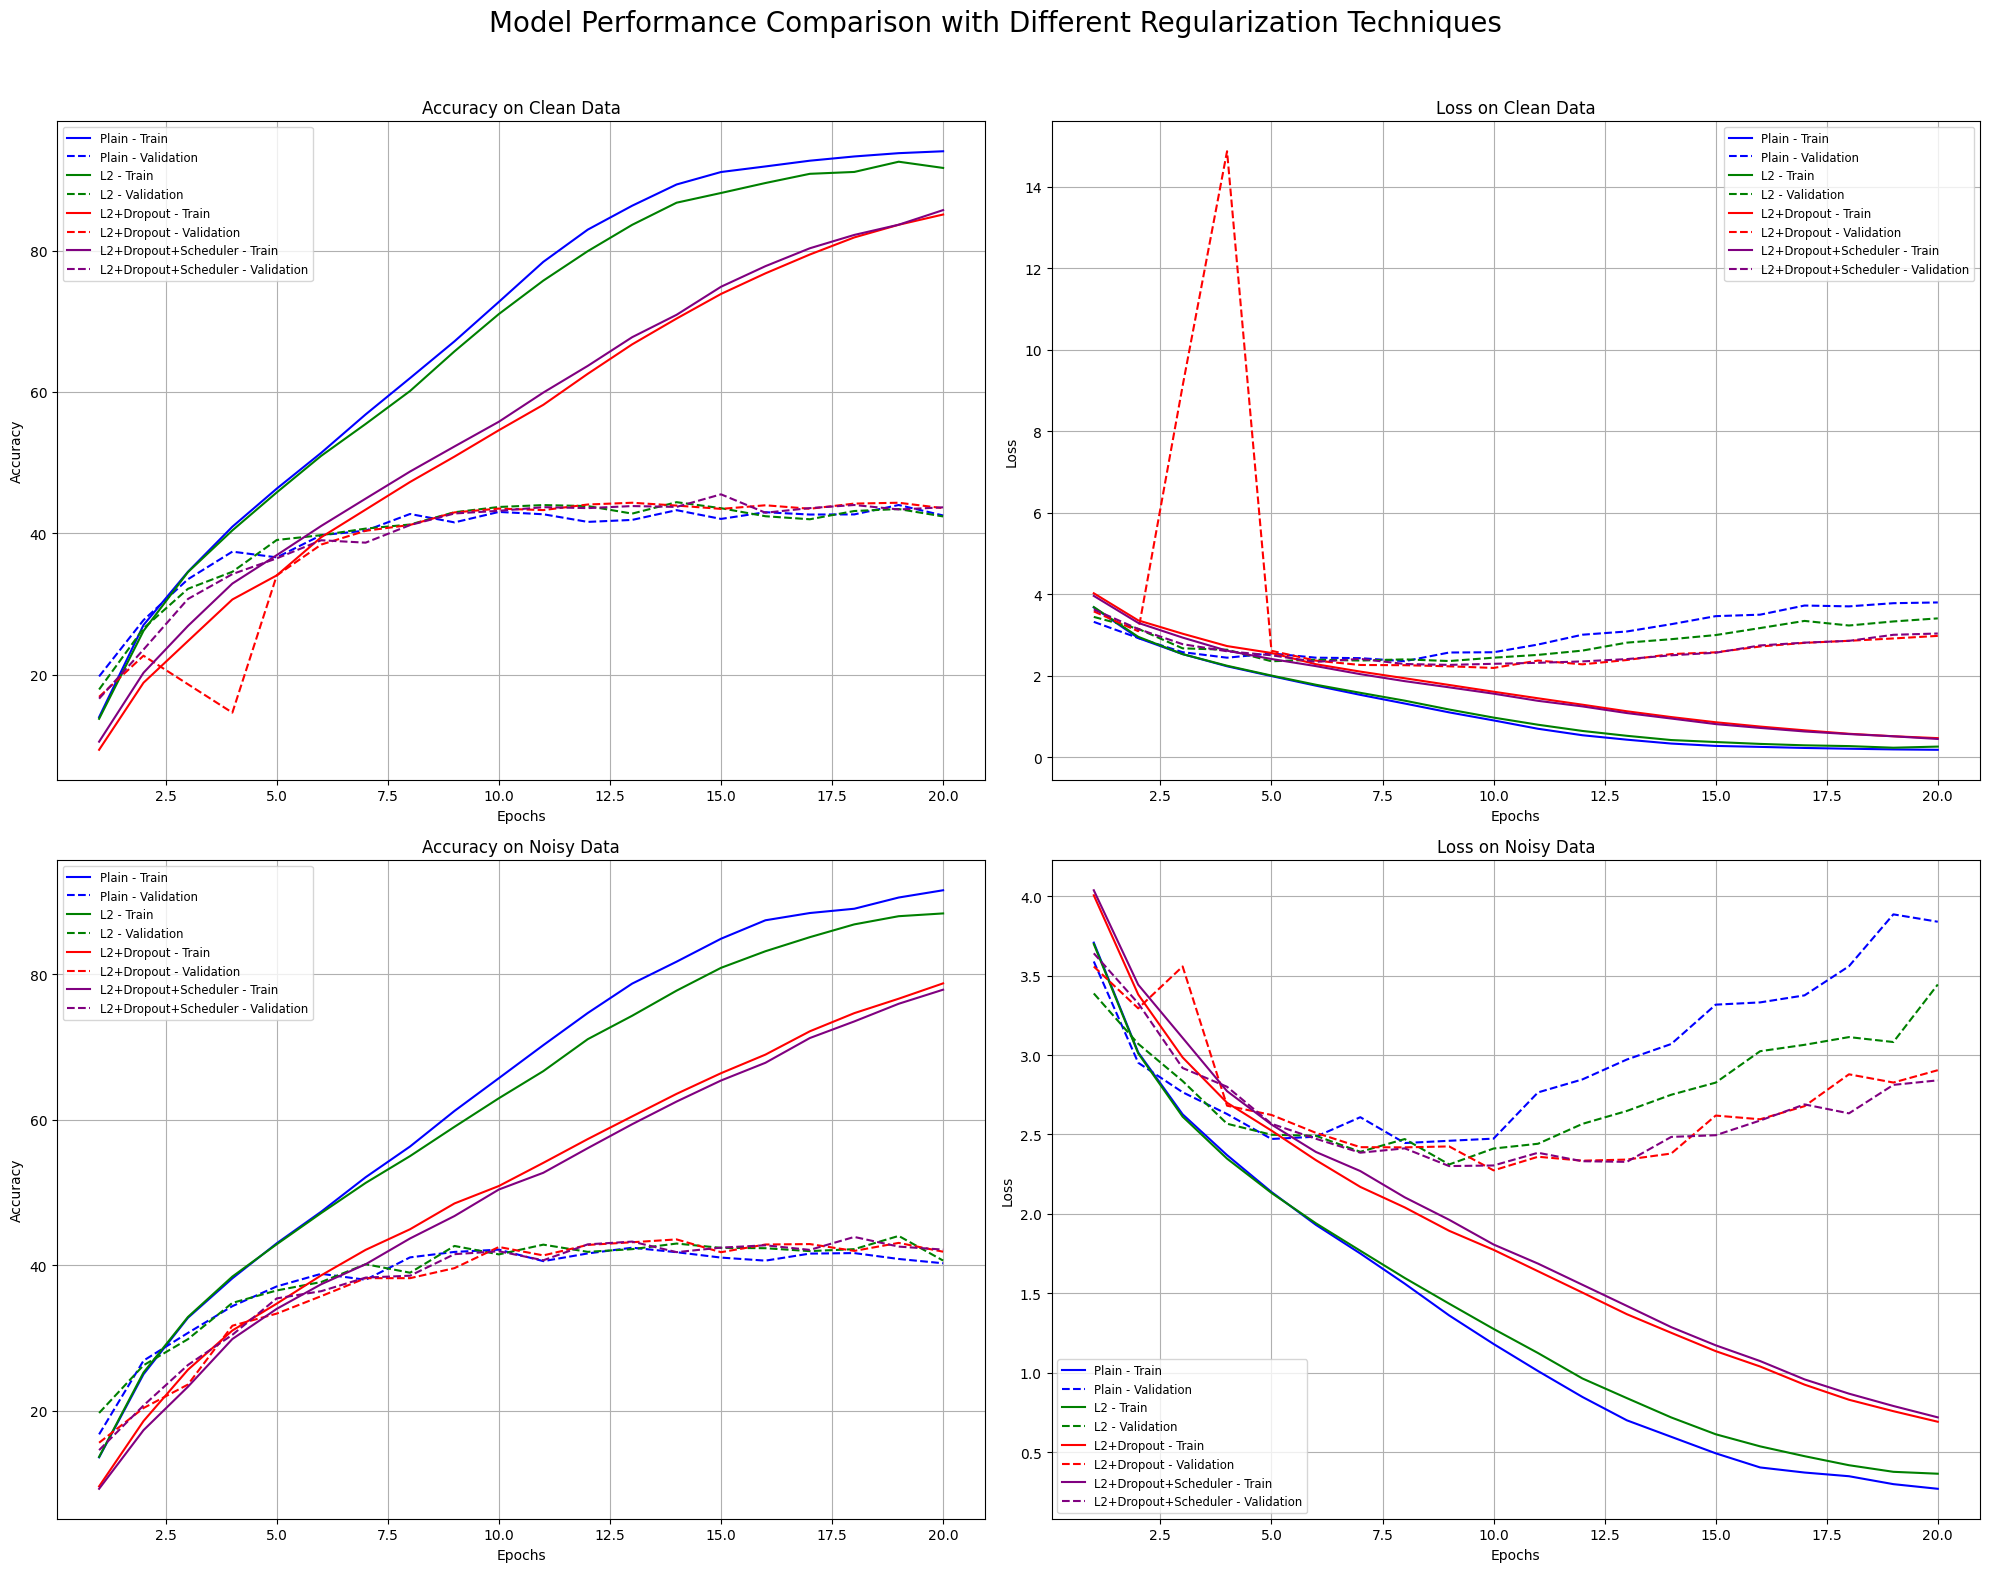

In [9]:
def plot_metrics(ax, history_dictionary, title):
    epochs_range = range(1, epochs + 1)
    
    colors = {
        'Plain': 'blue',
        'L2': 'green',
        'L2+Dropout': 'red',
        'L2+Dropout+Scheduler': 'purple'
    }
    
    for label, history in history_dictionary.items():
        color = colors[label]
        ax.plot(
            epochs_range, 
            history[0], 
            color=color, 
            linestyle='-', 
            label=f'{label} - Train'
        )
        ax.plot(
            epochs_range, 
            history[1], 
            color=color, 
            linestyle='--', 
            label=f'{label} - Validation'
        )
        
    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.set_ylabel(title.split(' ')[0])
    ax.legend(loc='best', fontsize='small')
    ax.grid(True)

histories_clean_acc = {
    'Plain': (history_clean_plain['train_acc'], history_clean_plain['val_acc']),
    'L2': (history_clean_l2['train_acc'], history_clean_l2['val_acc']),
    'L2+Dropout': (history_clean_l2_dropout['train_acc'], history_clean_l2_dropout['val_acc']),
    'L2+Dropout+Scheduler': (history_clean_l2_dropout_scheduler['train_acc'], history_clean_l2_dropout_scheduler['val_acc'])
}

histories_clean_loss = {
    'Plain': (history_clean_plain['train_loss'], history_clean_plain['val_loss']),
    'L2': (history_clean_l2['train_loss'], history_clean_l2['val_loss']),
    'L2+Dropout': (history_clean_l2_dropout['train_loss'], history_clean_l2_dropout['val_loss']),
    'L2+Dropout+Scheduler': (history_clean_l2_dropout_scheduler['train_loss'], history_clean_l2_dropout_scheduler['val_loss'])
}

histories_noisy_acc = {
    'Plain': (history_noisy_plain['train_acc'], history_noisy_plain['val_acc']),
    'L2': (history_noisy_l2['train_acc'], history_noisy_l2['val_acc']),
    'L2+Dropout': (history_noisy_l2_dropout['train_acc'], history_noisy_l2_dropout['val_acc']),
    'L2+Dropout+Scheduler': (history_noisy_l2_dropout_scheduler['train_acc'], history_noisy_l2_dropout_scheduler['val_acc'])
}

histories_noisy_loss = {
    'Plain': (history_noisy_plain['train_loss'], history_noisy_plain['val_loss']),
    'L2': (history_noisy_l2['train_loss'], history_noisy_l2['val_loss']),
    'L2+Dropout': (history_noisy_l2_dropout['train_loss'], history_noisy_l2_dropout['val_loss']),
    'L2+Dropout+Scheduler': (history_noisy_l2_dropout_scheduler['train_loss'], history_noisy_l2_dropout_scheduler['val_loss'])
}


fig, axs = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Model Performance Comparison with Different Regularization Techniques', fontsize=20)

plot_metrics(axs[0, 0], histories_clean_acc, 'Accuracy on Clean Data')
plot_metrics(axs[0, 1], histories_clean_loss, 'Loss on Clean Data')

plot_metrics(axs[1, 0], histories_noisy_acc, 'Accuracy on Noisy Data')
plot_metrics(axs[1, 1], histories_noisy_loss, 'Loss on Noisy Data')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

As we can see all he models had quite similar performance on the validation data (which is the important one) so we can't just judge them based on these plots and we are going to use tables to draw the final conclusion in the next section. From these plots one thing that stands out is the fact that all the models have overfitted at around 7 epochs (the loss on the validation data began increasing and the accuracy stayed the same) 

### 1-1-5. Comparing the model performances

To be able to better analyse the performance of the models we are going to get the best results of all the models and put them in a table.

In [ ]:
import pandas as pd

data_summary = []

histories = {
    ('Clean', '1. Plain'): history_clean_plain,
    ('Clean', '2. L2'): history_clean_l2,
    ('Clean', '3. L2 + Dropout'): history_clean_l2_dropout,
    ('Clean', '4. L2 + Dropout + Scheduler'): history_clean_l2_dropout_scheduler,
    ('Noisy', '1. Plain'): history_noisy_plain,
    ('Noisy', '2. L2'): history_noisy_l2,
    ('Noisy', '3. L2 + Dropout'): history_noisy_l2_dropout,
    ('Noisy', '4. L2 + Dropout + Scheduler'): history_noisy_l2_dropout_scheduler
}

for (data_type, model_name), history in histories.items():
    data_summary.append({
        'Training Data': data_type,
        'Strategy': model_name,
        'Best Val Accuracy (%)': max(history['val_acc']),
        'Best Val Loss': min(history['val_loss'])
    })

data_summary_df = pd.DataFrame(data_summary)

styled_df = data_summary_df.style.format({
    'Best Val Accuracy (%)': '{:.2f}',
    'Best Val Loss': '{:.4f}'
}).hide(axis='index').set_properties(**{'text-align': 'left'})

display(styled_df)

Training Data,Strategy,Best Val Accuracy (%),Best Val Loss
Clean,1. Plain,44.00,2.3560
Clean,2. L2,44.40,2.3540
Clean,3. L2 + Dropout,44.32,2.1903
Clean,4. L2 + Dropout + Scheduler,45.51,2.2650
Noisy,1. Plain,42.41,2.4462
Noisy,2. L2,44.03,2.3112
Noisy,3. L2 + Dropout,43.55,2.2740
Noisy,4. L2 + Dropout + Scheduler,43.89,2.3010


From this table we can see that the best model on clean data was the one that only used all methods and the best model on the noisy data was the one that used L2, but since the performance on the noisy data between the models were very close between the L2 + Dropout + Scheduler model and L2 model we are going to choose the model that used all the methods for the future parts (we are going to train it once again and keep the best during the training process)

If we compare the results on clean (45.51%) and noisy (43.89%), we can see despite the noise disturbing the data, the model managed to filter it and the performance drop was less than 2%, this could be due to the fact that ResNet is a rather large model and has a good generalization capability and it can easily filter out noise.

As for the low performance of the model, we can propose two theories: 1. The model did not have enough input data or 2. The model was not complex enough to be able to separate the data. Since ResNet is a rather big and powerful model the first theory is more likely and in order to improve the performance we could use data augmentation but since it is not the goal of this project we will leave it at that.

In [6]:
from torch.optim.lr_scheduler import StepLR

epochs = 20
learning_rate = 0.001
num_classes = 100
dropout_rate = 0.5

resNet_clean = models.resnet34(weights=None)
resNet_clean.fc = nn.Sequential(
    nn.Dropout(p=dropout_rate),
    nn.Linear(resNet_clean.fc.in_features, 100)
)
resNet_clean.to(device)

resNet_noisy = models.resnet34(weights=None)
resNet_noisy.fc = nn.Sequential(
    nn.Dropout(p=dropout_rate),
    nn.Linear(resNet_noisy.fc.in_features, 100)
)
resNet_noisy.to(device)

criterion = nn.CrossEntropyLoss()


optimizer_clean = optim.Adam(
    resNet_clean.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
optimizer_noisy = optim.Adam(
    resNet_noisy.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

scheduler_noisy = StepLR(optimizer_noisy, step_size=7, gamma=0.1)
scheduler_clean = StepLR(optimizer_clean, step_size=7, gamma=0.1)

print("Training the model on clean data")
history_clean_l2_dropout_scheduler, best_resNet_clean = train_and_validate(
    resNet_clean, 
    train_loader_clean,
    test_loader,
    optimizer_clean,
    criterion,
    epochs,
    scheduler_clean,
    keep_best=True
)
resNet_clean.load_state_dict(best_resNet_clean)

print()
print("Training the model on noisy data")
history_noisy_l2_dropout_scheduler, best_resNet_noisy = train_and_validate(
    resNet_noisy,
    train_loader_noisy,
    test_loader,
    optimizer_noisy,
    criterion,
    epochs,
    scheduler_noisy,
    keep_best=True
)
resNet_noisy.load_state_dict(best_resNet_noisy)

Training the model on clean data
Epoch 1: New best model saved with Val Acc: 15.86%
Epoch 1/20 | Train Loss: 4.0513 | Train Acc: 9.31% | Val Loss: 3.6643 | Val Acc: 15.86%
Epoch 2: New best model saved with Val Acc: 24.97%
Epoch 2/20 | Train Loss: 3.3831 | Train Acc: 18.71% | Val Loss: 3.0446 | Val Acc: 24.97%
Epoch 3: New best model saved with Val Acc: 29.79%
Epoch 3/20 | Train Loss: 2.9516 | Train Acc: 26.25% | Val Loss: 2.7736 | Val Acc: 29.79%
Epoch 4: New best model saved with Val Acc: 32.45%
Epoch 4/20 | Train Loss: 2.6925 | Train Acc: 31.46% | Val Loss: 2.6539 | Val Acc: 32.45%
Epoch 5: New best model saved with Val Acc: 36.84%
Epoch 5/20 | Train Loss: 2.4455 | Train Acc: 36.27% | Val Loss: 2.4039 | Val Acc: 36.84%
Epoch 6: New best model saved with Val Acc: 38.30%
Epoch 6/20 | Train Loss: 2.2515 | Train Acc: 40.35% | Val Loss: 2.3540 | Val Acc: 38.30%
Epoch 7: New best model saved with Val Acc: 40.95%
Epoch 7/20 | Train Loss: 2.0717 | Train Acc: 44.14% | Val Loss: 2.2569 | Val 

KeyboardInterrupt: 

Removing the old models to free up the vram

In [12]:
del model_clean_plain
del model_noisy_plain
del model_clean_l2
del model_noisy_l2
del model_clean_l2_dropout
del model_noisy_l2_dropout
del model_clean_l2_dropout_scheduler
del model_noisy_l2_dropout_scheduler

del optimizer_clean_plain
del optimizer_noisy_plain
del optimizer_clean_l2
del optimizer_noisy_l2
del optimizer_clean_l2_dropout
del optimizer_noisy_l2_dropout
del optimizer_clean_l2_dropout_scheduler
del optimizer_noisy_l2_dropout_scheduler

torch.cuda.empty_cache()

## 1-2. Transfer learning on Flowers-102 dataset

### 1-2-0. Loading and preprocessing the dataset

We will be using the flowers-102 dataset which is a collection of images of common flowers in UK and contains 102 different classes with over 8,000 images.

In this section we will download it and prepare the appropriate data loaders and transform the images to work with the ViT, we will also use random Horizontal flips and random rotations to augment the data to improve the performance of the model!

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_validation_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_flowers = torchvision.datasets.Flowers102(
    root='./data', 
    split='train',
    download=True, 
    transform=transform_train
)

validation_flowers = torchvision.datasets.Flowers102(
    root='./data', 
    split='val',
    download=True, 
    transform=transform_validation_test
)

test_flowers = torchvision.datasets.Flowers102(
    root='./data', 
    split='test',
    download=True, 
    transform=transform_validation_test
)

batch_size = 16
train_loader_flowers = torch.utils.data.DataLoader(
    train_flowers, 
    batch_size=batch_size,
    shuffle=True, 
    num_workers=2
)

val_loader_flowers = torch.utils.data.DataLoader(
    validation_flowers, 
    batch_size=batch_size,
    shuffle=False, 
    num_workers=2
)

test_loader_flowers = torch.utils.data.DataLoader(
    test_flowers, 
    batch_size=batch_size,
    shuffle=False, 
    num_workers=2
)


print(len(train_flowers))
print(len(validation_flowers))
print(len(test_flowers))

1020
1020
6149


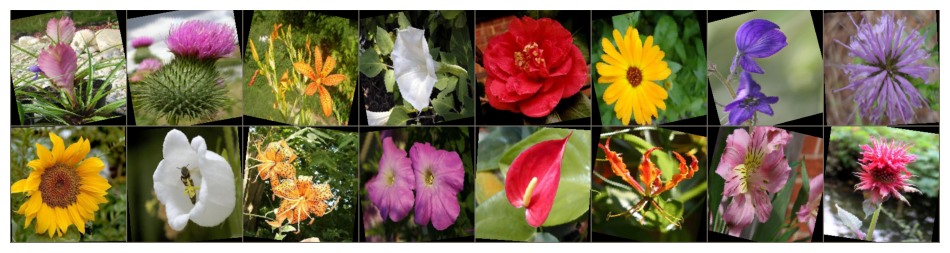

In [ ]:
def show_flower_images(image_tensor):
    image_grid = torchvision.utils.make_grid(image_tensor)
    
    np_image = image_grid.numpy().transpose((1, 2, 0))
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    np_image = std * np_image + mean
    np_image = np.clip(np_image, 0, 1)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(np_image)
    plt.axis('off')
    plt.show()

images, labels = next(iter(train_loader_flowers))

show_flower_images(images)

### 1-2-1. Loading the pre-trained model

We will load the pre-trained vit_base_patch16_224 model from torchvision and change its output layer to accommodate the 102 classes of our dataset. Since we are going to use transfer learning we are also going to freeze all the parameters in the backbone of the model and only allow the classification head to be trained.

In [ ]:
weights = models.ViT_B_16_Weights.IMAGENET1K_V1
vit_model_pretrained = models.vit_b_16(weights=weights)

for param in vit_model_pretrained.parameters():
    param.requires_grad = False

num_classes = 102
in_features = vit_model_pretrained.heads.head.in_features

vit_model_pretrained.heads = nn.Linear(in_features=in_features, out_features=num_classes)

vit_model_pretrained.to(device)

print(vit_model_pretrained.heads)

total_parameters = sum(parameter.numel() for parameter in vit_model_pretrained.parameters())
trainable_parameters = sum(parameter.numel() for parameter in vit_model_pretrained.parameters() if parameter.requires_grad)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Linear(in_features=768, out_features=102, bias=True)
Total parameters: 85,877,094
Trainable parameters: 78,438


### 1-2-2. Fine tuning on Flowers-102

Now we will fine tune the model for 5 epochs on the flowers-102 dataset and keep the best model. 

In [ ]:
epochs_vit_pretrained = 5
learning_rate_ViT_pretrained = 0.001

criterion_vit = nn.CrossEntropyLoss()

parameters_to_update = filter(lambda parameter: parameter.requires_grad, vit_model_pretrained.parameters())
optimizer_vit = optim.Adam(
    parameters_to_update, 
    lr=learning_rate_ViT_pretrained,
    weight_decay=1e-4
)

print("Fine-tuning the ViT model on Flowers-102")

history_vit_pretrained, best_vit_model_pretrained = train_and_validate(
    model=vit_model_pretrained,
    train_loader=train_loader_flowers,
    test_loader=val_loader_flowers,
    optimizer=optimizer_vit,
    criterion=criterion_vit,
    epochs=epochs_vit_pretrained,
    keep_best=True
)

vit_model_pretrained.load_state_dict(best_vit_model_pretrained)

Fine-tuning the ViT model on Flowers-102
Epoch 1: New best model saved with Val Acc: 55.69%
Epoch 1/5 | Train Loss: 3.9179 | Train Acc: 22.84% | Val Loss: 2.7453 | Val Acc: 55.69%
Epoch 2: New best model saved with Val Acc: 69.02%
Epoch 2/5 | Train Loss: 1.9553 | Train Acc: 74.61% | Val Loss: 1.8248 | Val Acc: 69.02%
Epoch 3: New best model saved with Val Acc: 76.08%
Epoch 3/5 | Train Loss: 1.1360 | Train Acc: 87.94% | Val Loss: 1.4090 | Val Acc: 76.08%
Epoch 4: New best model saved with Val Acc: 79.31%
Epoch 4/5 | Train Loss: 0.7256 | Train Acc: 94.80% | Val Loss: 1.1708 | Val Acc: 79.31%
Epoch 5: New best model saved with Val Acc: 80.59%
Epoch 5/5 | Train Loss: 0.5135 | Train Acc: 96.76% | Val Loss: 1.0475 | Val Acc: 80.59%
Finished Training. Total time: 2.03 minutes


<All keys matched successfully>

In order to get the best results after fine tuning the parameters we landed on a learning rate of 0.001 and a regularization factor (weight_decay) of 0.0001

The pre-trained model managed to get a respectable 80% accuracy on the validation data. Looking at the trend we can see the signs of overfitting so I assume even with more epochs the performance would not improve much. 

### 1-2-2. Loading & training the ViT from scratch

Now we will load the same model but this time without the weights and train the model from scratch on the dataset, originally the model was trained for about 10 epochs but since there was still some room for improvement we let the model to be trained for 30 epochs.

In [ ]:
epochs_vit_scratch = 30
learning_rate_vit_scratch = 0.00001

vit_model_scratch = models.vit_b_16(weights=None)

num_classes = 102
in_features_scratch = vit_model_scratch.heads.head.in_features
vit_model_scratch.heads = nn.Linear(in_features=in_features_scratch, out_features=num_classes)
vit_model_scratch.to(device)

optimizer_vit_scratch = optim.Adam(
    vit_model_scratch.parameters(), 
    lr=learning_rate_vit_scratch,
    weight_decay=1e-4
)

criterion_vit_scratch = nn.CrossEntropyLoss()

print("Training the ViT model from SCRATCH on Flowers-102")

history_vit_scratch, best_vit_model_scratch = train_and_validate(
    model=vit_model_scratch,
    train_loader=train_loader_flowers,
    test_loader=val_loader_flowers,
    optimizer=optimizer_vit_scratch,
    criterion=criterion_vit_scratch,
    epochs=epochs_vit_scratch,
    keep_best=True
)

vit_model_scratch.load_state_dict(best_vit_model_scratch)

Training the ViT model from SCRATCH on Flowers-102
Epoch 1: New best model saved with Val Acc: 8.73%
Epoch 1/30 | Train Loss: 4.4987 | Train Acc: 4.12% | Val Loss: 4.0769 | Val Acc: 8.73%
Epoch 2: New best model saved with Val Acc: 13.63%
Epoch 2/30 | Train Loss: 3.8218 | Train Acc: 10.29% | Val Loss: 3.7322 | Val Acc: 13.63%
Epoch 3: New best model saved with Val Acc: 17.65%
Epoch 3/30 | Train Loss: 3.4006 | Train Acc: 18.04% | Val Loss: 3.5205 | Val Acc: 17.65%
Epoch 4: New best model saved with Val Acc: 20.49%
Epoch 4/30 | Train Loss: 3.0621 | Train Acc: 23.04% | Val Loss: 3.3278 | Val Acc: 20.49%
Epoch 5: New best model saved with Val Acc: 23.53%
Epoch 5/30 | Train Loss: 2.7736 | Train Acc: 29.12% | Val Loss: 3.2513 | Val Acc: 23.53%
Epoch 6: New best model saved with Val Acc: 25.29%
Epoch 6/30 | Train Loss: 2.4858 | Train Acc: 36.27% | Val Loss: 3.1459 | Val Acc: 25.29%
Epoch 7: New best model saved with Val Acc: 25.98%
Epoch 7/30 | Train Loss: 2.2478 | Train Acc: 42.25% | Val Los

<All keys matched successfully>

After extensive hyper-parameter tuning the best model was obtained by using L2 regularization with a parameter of 1e-4 and a learning rate of 1e-5.

After training for 30 epochs and keeping the best model it managed to get an accuracy of 35% on validation data but we can see clear signs of overfitting, which is to be expected given the massive size of the ViT model and the small size of our dataset.

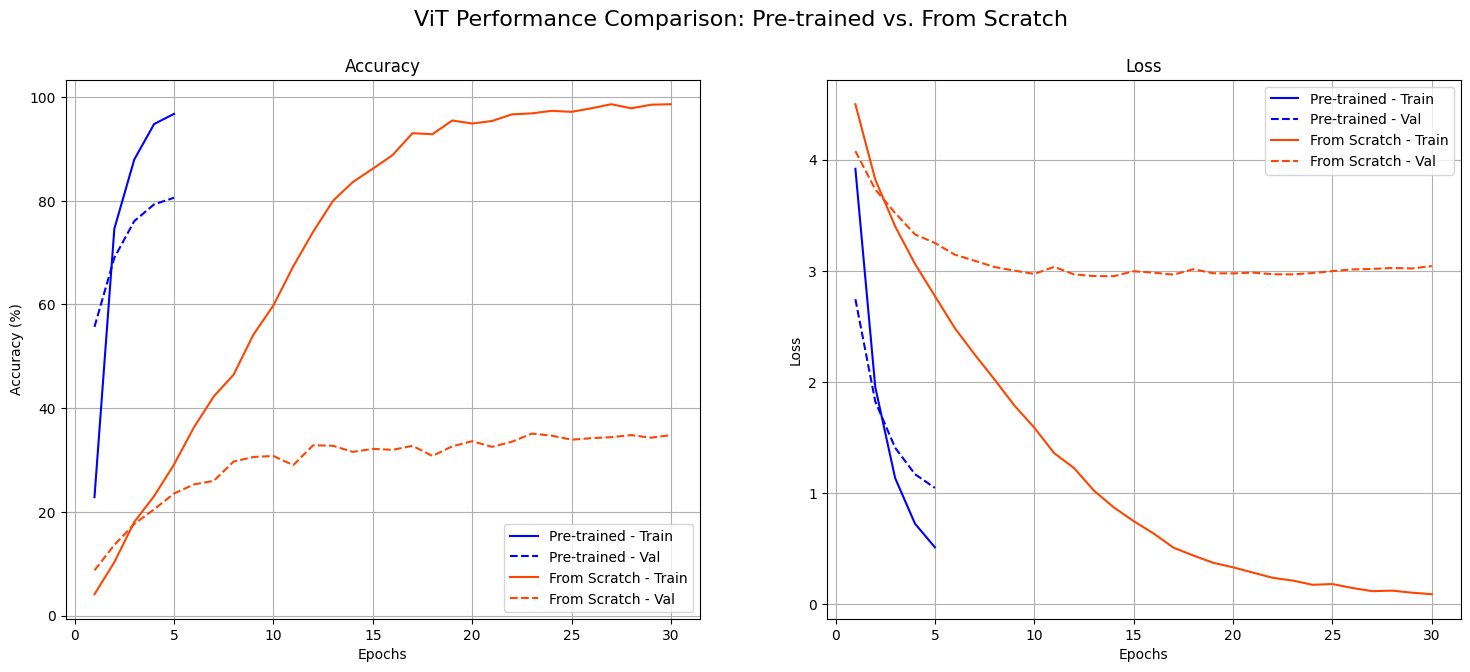

80.58823529411765
35.09803921568628


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('ViT Performance Comparison: Pre-trained vs. From Scratch', fontsize=16)

epochs_pretrained = len(history_vit_pretrained['val_acc'])
epochs_scratch = len(history_vit_scratch['val_acc'])
range_pretrained = range(1, epochs_pretrained + 1)
range_scratch = range(1, epochs_scratch + 1)

ax = axs[0]
ax.plot(range_pretrained, history_vit_pretrained['train_acc'], color='blue', linestyle='-', label='Pre-trained - Train')
ax.plot(range_pretrained, history_vit_pretrained['val_acc'], color='blue', linestyle='--', label='Pre-trained - Val')
ax.plot(range_scratch, history_vit_scratch['train_acc'], color='orangered', linestyle='-', label='From Scratch - Train')
ax.plot(range_scratch, history_vit_scratch['val_acc'], color='orangered', linestyle='--', label='From Scratch - Val')

ax.set_title('Accuracy')
ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True)


ax = axs[1]
ax.plot(range_pretrained, history_vit_pretrained['train_loss'], color='blue', linestyle='-', label='Pre-trained - Train')
ax.plot(range_pretrained, history_vit_pretrained['val_loss'], color='blue', linestyle='--', label='Pre-trained - Val')
ax.plot(range_scratch, history_vit_scratch['train_loss'], color='orangered', linestyle='-', label='From Scratch - Train')
ax.plot(range_scratch, history_vit_scratch['val_loss'], color='orangered', linestyle='--', label='From Scratch - Val')

ax.set_title('Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.show()

print(max(history_vit_pretrained['val_acc']))
print(max(history_vit_scratch['val_acc']))

We can see that both models have been trained an some signs of overfitting are visible (especially in the from scratch version).

At the end the pre-trained model got an accuracy of 80% and the scratch model got an accuracy of 35%. This massive gap in performance shows the power of the pre-training, especially in ViTs.

The pre-trained model has been trained on the ImageNet dataset which is vast library of over a million images across 1000 classes, training the model on this dataset taught it how to extract rich features from the images so when we wanted to apply this model to the our flowers dataset, we only needed to train the classifier portion (and teach the model how to use its rich features to distinguish the flowers).

In contrast the scratch model only had the limited flowers dataset to train on, since unlike CNN model, vision transformer models have no inherit knowledge of the image, they need to learn the concepts of edges, shapes etc from scratch and this, along with their massive number of parameters causes them to require a lot of data, which in our case was not present. So they mostlikely overfit and have very low performance as we saw.

## 1-3. Adversarial attack and defense

In this section we are going to check the performance of the previous models against FGSM and PGD attacks and defend them with adversarial training!

### 1-3-0. Explaining adversarial attacks, FGSM and PGD

Before we begin I've copy and pasted the definition of these terms form one of my previous reports to explain these in more detail:


__Adversarial attacks__: As the paper described, an adversarial attack adds a small imperceptible perturbation to an original image to create a new image with the goal of crafting an image to maximize the model's prediction error or loss.

__Fast Gradient Sign Method (FGSM)__:
    (based on this intro from tensor flow: https://www.tensorflow.org/tutorials/generative/adversarial_fgsm)
    FGSM is a fast method for generating adversarial examples. It works by exploiting how the model's loss function behaves to maximize the model's loss by making only a single change to the input image. (each pixel)
    The process involves the following steps:
        
* Calculating the gradient: FGSM first calculates the gradient of the model's loss function with respect to the pixels of the input image to find the direction in which to change the pixel values to achieve the maximum increase in the loss.
        
* Finding the sign: Instead of using the gradient values, FGSM only uses the sign of each element in the gradient. meaning for each pixel it determines if the value should be increased (+1) or decreased (-1) to maximize the loss.
        
* Apply the perturbation: The sign vector is then multiplied by a small scalar epsilon, that controls the overall magnitude of the perturbation.

The formula is:

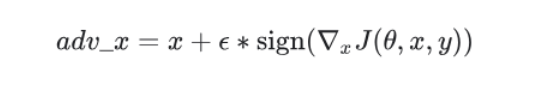



__Projected Gradient Descent (PGD)__:
    According to this article on medium (https://medium.com/@zachariaharungeorge/unveiling-the-power-of-projected-gradient-descent-in-adversarial-attacks-2f92509dde3c)
    PGD is an iterative extension of the basic adversarial idea. Instead of taking one large step, PGD takes multiple smaller steps that make it more likely to find a successful perturbation.

The process consists of the following steps:

* Initialization: It starts by taking a small and random step away from the original image but still within the allowed area.

* Iterative Steps: For a number of steps it calculates the gradient just like in FGSM, and the gradient of the loss is calculated with respect to the current pixels of the perturbed image. Then it takes a small step in the direction of the gradient's sign. the size of this step is determined by a step size parameter, denoted as alpha. (for example in the paper, they used a step size of alpha = 1/255 for their PGD attacks.) After each step, the new perturbed image may have moved outside the allowed area around the original image. The projection step forces the image back into this boundary by clipping the perturbation to ensure its magnitude does not exceed the allowed value (epsilon).
        
Because PGD is an iterative process that explores the area around the image more thoroughly, it is considered a much stronger attack than FGSM and is a standard benchmark for evaluating a model's adversarial robustness.

### 1-3-1. Implementing FGSM & PGD

In this part we will implement a couple of functions that take a model a batch of images and labels and the attack parameters and generate a batch of corresponding adversarial images.

#### 1-3-1-1. FGSM

The FGSM attack works by taking a single step in the direction of the gradient of the loss with respect to the input image. So we do just that and at the end clip the image to the valid range to prevent any issues.

In [ ]:
def fgsm_attack(model, loss_function, image, label, epsilon):
    image.requires_grad = True
    
    output = model(image)
    
    loss = loss_function(output, label)
    
    model.zero_grad()
    
    loss.backward()
    
    gradient = image.grad.data
    
    sign_gradient = gradient.sign()
    
    perturbed_image = image + epsilon * sign_gradient
    
    perturbed_image = torch.clamp(perturbed_image, image.min(), image.max())
    
    return perturbed_image

#### 1-3-1-2. PGD

PGD is a more powerful, iterative version of FGSM. Instead of taking one large step, it takes multiple small steps and after each step it projects the result back into a small, allowed zone (epsilon-ball) around the original image. So in order to implemented we have to repeat the same process multiple times.

In [ ]:
def pgd_attack(model, loss_function, image, label, epsilon, alpha, iterations):
    original_image = image.data.clone().detach()
    
    perturbed_image = image.data.clone().detach()

    for i in range(iterations):
        perturbed_image.requires_grad = True
        
        output = model(perturbed_image)
        
        loss = loss_function(output, label)
        
        model.zero_grad()
        
        loss.backward()
        
        gradient_sign = perturbed_image.grad.data.sign()
        
        perturbed_image = perturbed_image.detach() + alpha * gradient_sign
        
        eta = torch.clamp(perturbed_image - original_image, min=-epsilon, max=epsilon)
        
        perturbed_image = torch.clamp(original_image + eta, min=image.min(), max=image.max())

    return perturbed_image

### 1-3-2. Generating adversarial images and testing the models

In this section we are going to generate adversarial images for our chosen models (ResNet on clean data, ResNet on noisy data, pretrained ViT and scratch ViT) and test their performance on these adversarial samples.

In [ ]:
def test_adversarial(model, device, test_loader, attack_function=None, attack_params=None):
    correct = 0
    total = 0
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        if attack_function:
            images = attack_function(model, criterion, images, labels, **attack_params)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    accuracy = 100 * correct / total
    return accuracy


In [ ]:
models_to_test = {
    "ResNet (Clean)": {"model": resNet_clean, "loader": test_loader},
    "ResNet (Noisy)": {"model": resNet_noisy, "loader": test_loader},
    "ViT (Pre-trained)": {"model": vit_model_pretrained, "loader": test_loader_flowers},
    "ViT (From Scratch)": {"model": vit_model_scratch, "loader": test_loader_flowers},
}

epsilon = 0.1
pgd_params = {'epsilon': epsilon, 'alpha': 0.02, 'iterations': 7}
fgsm_params = {'epsilon': epsilon}

results_data = []
for name, data in models_to_test.items():
    model = data["model"]
    loader = data["loader"]
    print(f"Evaluating Model: {name}")

    acc_clean = test_adversarial(model, device, loader)
    print(f"    Accuracy on clean images: {acc_clean:.2f}%")

    acc_fgsm = test_adversarial(model, device, loader, fgsm_attack, fgsm_params)
    print(f"    Accuracy under FGSM attack (e={epsilon}): {acc_fgsm:.2f}%")

    acc_pgd = test_adversarial(model, device, loader, pgd_attack, pgd_params)
    print(f"    Accuracy under PGD attack (e={epsilon}): {acc_pgd:.2f}%")
    
    results_data.append({
        "Model": name,
        "Natural Acc. (%)": acc_clean,
        "FGSM Acc. (%)": acc_fgsm,
        "PGD Acc. (%)": acc_pgd,
    })

Evaluating Model: ResNet (Clean)
    Accuracy on clean images: 46.56%
    Accuracy under FGSM attack (e=0.1): 3.37%
    Accuracy under PGD attack (e=0.1): 0.99%
Evaluating Model: ResNet (Noisy)
    Accuracy on clean images: 45.23%
    Accuracy under FGSM attack (e=0.1): 4.75%
    Accuracy under PGD attack (e=0.1): 1.63%
Evaluating Model: ViT (Pre-trained)
    Accuracy on clean images: 78.37%
    Accuracy under FGSM attack (e=0.1): 1.04%
    Accuracy under PGD attack (e=0.1): 0.00%
Evaluating Model: ViT (From Scratch)
    Accuracy on clean images: 30.25%
    Accuracy under FGSM attack (e=0.1): 0.15%
    Accuracy under PGD attack (e=0.1): 0.03%


In [19]:
import pandas as pd
print(results_data)
df_results = pd.DataFrame(results_data)
styled_df = df_results.style.hide(axis='index').set_properties(**{'text-align': 'center'})
display(styled_df)

[{'Model': 'ResNet (Clean)', 'Natural Acc. (%)': 46.56, 'FGSM Acc. (%)': 3.37, 'PGD Acc. (%)': 0.99}, {'Model': 'ResNet (Noisy)', 'Natural Acc. (%)': 45.23, 'FGSM Acc. (%)': 4.75, 'PGD Acc. (%)': 1.63}, {'Model': 'ViT (Pre-trained)', 'Natural Acc. (%)': 78.37046674255977, 'FGSM Acc. (%)': 1.0408196454708083, 'PGD Acc. (%)': 0.0}, {'Model': 'ViT (From Scratch)', 'Natural Acc. (%)': 30.248820946495364, 'FGSM Acc. (%)': 0.14636526264433242, 'PGD Acc. (%)': 0.03252561392096276}]


Model,Natural Acc. (%),FGSM Acc. (%),PGD Acc. (%)
ResNet (Clean),46.560000,3.370000,0.990000
ResNet (Noisy),45.230000,4.750000,1.630000
ViT (Pre-trained),78.370467,1.040820,0.000000
ViT (From Scratch),30.248821,0.146365,0.032526


* the inconsistency in model accuracies are because I had to run the code several times! :(

As we can see both attacks were quite effective on the models, FGSM managed to reduce the performance of the ResNet models to below 6% (from ~45) and the ViT to 1%! 

But as expected, PGD (which is a more sufisticated attack) dropped the performance of the ResNets to less than 2.5% and ViT to 0!

An intreating observation here is that the ResNet model trained on the noisy data was ever so slightly more resilient against these attacks, which shows adding noise can improve model's defense!

### 1-3-3. Adversarial training

In this section we are going to perform adversarial training on the 4 models to make them stronger against attack. To do this we will define a new function for training (adversarial training) which is similar to the normal training function with the minor difference of using adversarial images.

In [ ]:
def adversarial_train(
        model, 
        device, 
        train_loader, 
        val_loader, 
        optimizer, 
        criterion, 
        epochs, 
        attack_fn, 
        attack_params
    ):
    history = {
        'train_loss': [], 
        'train_acc': [], 
        'val_loss': [], 
        'val_acc': []
    }
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            adversarial_inputs = attack_fn(
                model, 
                criterion, 
                inputs, 
                labels, 
                **attack_params
            )
            
            optimizer.zero_grad()
            outputs = model(adversarial_inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        model.eval()
        correct_val, total_val, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        history['train_loss'].append(running_loss / len(train_loader))
        history['train_acc'].append(100 * correct_train / total_train)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(100 * correct_val / total_val)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}%")
        
    return model, history

In order to keep the training stable, we will use a slightly weaker attack.

In [ ]:
model_configs = [
    {
        "name": "ResNet (Clean Data)",
        "original_model": resNet_clean,
        "arch_fn": lambda: models.resnet34(weights=None),
        "fc_fn": lambda m: nn.Linear(m.fc.in_features, 100),
        "train_loader": train_loader_clean,
        "test_loader": test_loader,
        "optimizer_params": {'lr': 0.001, 'weight_decay': 1e-4},
    },
    {
        "name": "ResNet (Noisy Data)",
        "original_model": resNet_noisy,
        "arch_fn": lambda: models.resnet34(weights=None),
        "fc_fn": lambda m: nn.Linear(m.fc.in_features, 100),
        "train_loader": train_loader_noisy,
        "test_loader": test_loader,
        "optimizer_params": {'lr': 0.001, 'weight_decay': 1e-4},
    },
    {
        "name": "ViT (Pre-trained)",
        "original_model": vit_model_pretrained,
        "arch_fn": lambda: models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1),
        "fc_fn": lambda m: nn.Linear(m.heads.head.in_features, 102),
        "train_loader": train_loader_flowers,
        "test_loader": test_loader_flowers,
        "optimizer_params": {'lr': 1e-5},
    },
    {
        "name": "ViT (From Scratch)",
        "original_model": vit_model_scratch,
        "arch_fn": lambda: models.vit_b_16(weights=None),
        "fc_fn": lambda m: nn.Linear(m.heads.head.in_features, 102),
        "train_loader": train_loader_flowers,
        "test_loader": test_loader_flowers,
        "optimizer_params": {'lr': 1e-5},
    }
]

adversarial_train_params = {'epsilon': 8/255, 'alpha': 2/255, 'iterations': 7}
evaluation_fgsm_params = {'epsilon': 0.1}
evaluation_pgd_params = {'epsilon': 0.1, 'alpha': 0.02, 'iterations': 7}
num_epochs_adversarial = 10

final_results_data = []

for config in model_configs:
    name = config["name"]
    original_model = config["original_model"]
    train_loader = config["train_loader"]
    test_loader = config["test_loader"]
    print("=======================================")
    print(f"Processing: {name}")

    print("Adversarial training of a new model")
    defended_model = config["arch_fn"]()
    if "ResNet" in name:
        defended_model.fc = config["fc_fn"](defended_model)
    else:
        if name == "ViT (Pre-trained)":
             for param in defended_model.parameters(): param.requires_grad = True
        defended_model.heads = config["fc_fn"](defended_model)
    
    optimizer = optim.Adam(defended_model.parameters(), **config["optimizer_params"])
    defended_model, _ = adversarial_train(
        defended_model, device, train_loader, test_loader, optimizer, nn.CrossEntropyLoss(), num_epochs_adversarial, pgd_attack, adversarial_train_params
    )

    print("Evaluating performance")
    accuracy_original_natural = test_adversarial(original_model, device, test_loader)
    accuracy_original_fgsm = test_adversarial(original_model, device, test_loader, fgsm_attack, evaluation_fgsm_params)
    accuracy_original_pgd = test_adversarial(original_model, device, test_loader, pgd_attack, evaluation_pgd_params)

    accuracy_defended_natural = test_adversarial(defended_model, device, test_loader)
    accuracy_defended_fgsm = test_adversarial(defended_model, device, test_loader, fgsm_attack, evaluation_fgsm_params)
    accuracy_defended_pgd = test_adversarial(defended_model, device, test_loader, pgd_attack, evaluation_pgd_params)

    final_results_data.append({
        "Model": name,
        "Clean Acc ": accuracy_original_natural,
        "FGSM Acc (Before)": accuracy_original_fgsm,
        "PGD Acc (Before)": accuracy_original_pgd,
        "Clean Acc (After)": accuracy_defended_natural,
        "FGSM Acc (After)": accuracy_defended_fgsm,
        "PGD Acc (After)": accuracy_defended_pgd
    })
    
    print("Cleaning up GPU memory")
    del defended_model
    del original_model
    torch.cuda.empty_cache()
    print("Memory cleared.")

Processing: ResNet (Clean Data)
Adversarial training of a new model


/pytorch/aten/src/ATen/native/cuda/Loss.cu:242: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [3,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:242: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [4,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:242: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [5,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:242: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [6,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:242: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [7,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:242: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [8,0,0] Assertion `t >= 0 && t < n_classes` failed.
/pytorch/aten/sr

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
print("Final Comparison Summary")
df_final = pd.DataFrame(final_results_data)
styled_df_final = df_final.style.format('{:.2f}').hide(axis='index').set_properties(**{'text-align': 'center'})
display(styled_df_final)